#**Curso de Especialização em Inteligência Artificial e Computacional**
**ELT 574 - Aprendizado de Máquinas**


## Semana 1 - Introdução ao Aprendizado de Máquinas

### Aula 01 - Introdução aos problemas de aprendizado de máquinas



#### Carregando as bibliotecas

In [2]:
## NumPy para manipular matrizes e vetores
import numpy as np

## Pandas para manipular os dataframes
import pandas as pd

## Plotar figuras bonitas
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
import seaborn as sns

print('Setup completo!')

Setup completo!


Etapas de construção de um modelo de ML:
1. Formulação do problema
2. Seleção e adaptação do banco de dados
3. Pré-processamento do banco de dados
4. Separação do banco de dados em dados de treinamento e validação
5. Ajuste do modelo com os dados de treinamento
6. Validação do modelo e estimativa de desempenho com os dados de validação
7. Implementação do modelo para aplicação

#### Importando  os dados para análise

##### Do Google Drive

In [4]:
# Se preferir, pode utilizar o Google Drive.
# Entretanto, da para utilizar tambem o proprio dataset do sklearn ou do GitHub

#Importando as bibliotecas para analise do problema e configurando o notebook

## OS para executar comandos de diretorio
# import os

## Habilitar Google Drive no Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### Do GitHub

In [7]:
# baixar o arquivo do GitHub
# o repositorio alvo eh o repositorio da disciplina
!wget https://github.com/rodolpho-neves/elt574-aprendizado-de-maquina/raw/main/semana-1/housing.csv

--2024-11-12 23:22:14--  https://github.com/rodolpho-neves/elt574-aprendizado-de-maquina/raw/main/semana-1/housing.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/nias-ufv/elt574-aprendizado-de-maquina/raw/main/semana-1/housing.csv [following]
--2024-11-12 23:22:14--  https://github.com/nias-ufv/elt574-aprendizado-de-maquina/raw/main/semana-1/housing.csv
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/nias-ufv/elt574-aprendizado-de-maquina/main/semana-1/housing.csv [following]
--2024-11-12 23:22:15--  https://raw.githubusercontent.com/nias-ufv/elt574-aprendizado-de-maquina/main/semana-1/housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting t

#### 1. Formulação do problema

*Estimar o valor médio das casas em um distrito da Califórnia, dado um determinado conjunto de dados e características deste distrito.*

Fonte: https://www.kaggle.com/camnugent/california-housing-prices

*Variáveis do banco de dados:*

- longitude: *Longitude*
- latitude - *Latitude*
- housing_median_age - *Idade média das construções no quarteirão*
- total_rooms - *Número de cômodos no quarteirão*
- total_bedrooms - *Número de quartos no quarteirão*
- population - *Número de pessoas que vivem no quarteirão*
- households - *Número de famílias vivendo no mesmo quarteirão*
- median_income - *Renda média mensal do quarteirão em que a casa está situada (medida em dezenas de milhares de dólares)*
- median_house_value (target) - *Valor médio das casas do quarteirão em que a casa está situada (em dólares)*
- ocean_proximity - *Proximidade da casa do oceano/mar*

#### 2. Seleção do banco de dados

In [8]:
## Importar os dados do banco de dados

# path do Google Drive
#path = '/content/drive/MyDrive/1-UFV/Disciplinas/Disciplinas Lato-Sensu/ELT 574 - Aprendizado de máquinas/Material da disciplina/Roteiros e aulas/Atividades/housing.csv'

# path do arquivo baixado do GitHub
path = '/content/housing.csv'

df_housing = pd.read_csv(path)
print('Dataset carregado!')

df_housing.head(20)

Dataset carregado!


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY




---


---


---


---


---


---



### Aula 02 - Tipos de dados e tratamento de entradas



#### Tipos de dados:
1. Qualitativos
 * Nominal
 * Ordinários

2. Quantitativos
 * Discreto
 * Contínuo

In [9]:
# Conhecendo o banco de dados
## Verificar se foi importado corretamente
df_housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
## Verificar informacoes gerais sobre as variaveis do dataframe
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Variável categórica : 'ocean_proximity'

In [ ]:
df_housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [ ]:
# filtrar amostras com
df_housing.loc[lambda x: x['ocean_proximity']=='ISLAND']

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8314,-118.32,33.35,27.0,1675.0,521.0,744.0,331.0,2.1579,450000.0,ISLAND
8315,-118.33,33.34,52.0,2359.0,591.0,1100.0,431.0,2.8333,414700.0,ISLAND
8316,-118.32,33.33,52.0,2127.0,512.0,733.0,288.0,3.3906,300000.0,ISLAND
8317,-118.32,33.34,52.0,996.0,264.0,341.0,160.0,2.7361,450000.0,ISLAND
8318,-118.48,33.43,29.0,716.0,214.0,422.0,173.0,2.6042,287500.0,ISLAND


In [11]:
df_housing.loc[df_housing['ocean_proximity']=='ISLAND',:]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8314,-118.32,33.35,27.0,1675.0,521.0,744.0,331.0,2.1579,450000.0,ISLAND
8315,-118.33,33.34,52.0,2359.0,591.0,1100.0,431.0,2.8333,414700.0,ISLAND
8316,-118.32,33.33,52.0,2127.0,512.0,733.0,288.0,3.3906,300000.0,ISLAND
8317,-118.32,33.34,52.0,996.0,264.0,341.0,160.0,2.7361,450000.0,ISLAND
8318,-118.48,33.43,29.0,716.0,214.0,422.0,173.0,2.6042,287500.0,ISLAND


In [12]:
df_housing.loc[df_housing['housing_median_age'] > 27,:]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20623,-121.37,39.03,32.0,1158.0,244.0,598.0,227.0,2.8235,65500.0,INLAND
20625,-121.52,39.12,37.0,102.0,17.0,29.0,14.0,4.1250,72000.0,INLAND
20626,-121.43,39.18,36.0,1124.0,184.0,504.0,171.0,2.1667,93800.0,INLAND
20629,-121.39,39.12,28.0,10035.0,1856.0,6912.0,1818.0,2.0943,108300.0,INLAND


#### Ferramentas para exploração de dados:



##### 1. Ferramentas descritivas
  * Medidas de tendências
    * Média
    * Mediana
    * Moda
 * Medidas de dispersão
    * Intervalo
    * Desvio padrão
 * Distribuição das frequências
 * Histogramas

In [13]:
# Medidas de tendencia e dispersao
df_housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


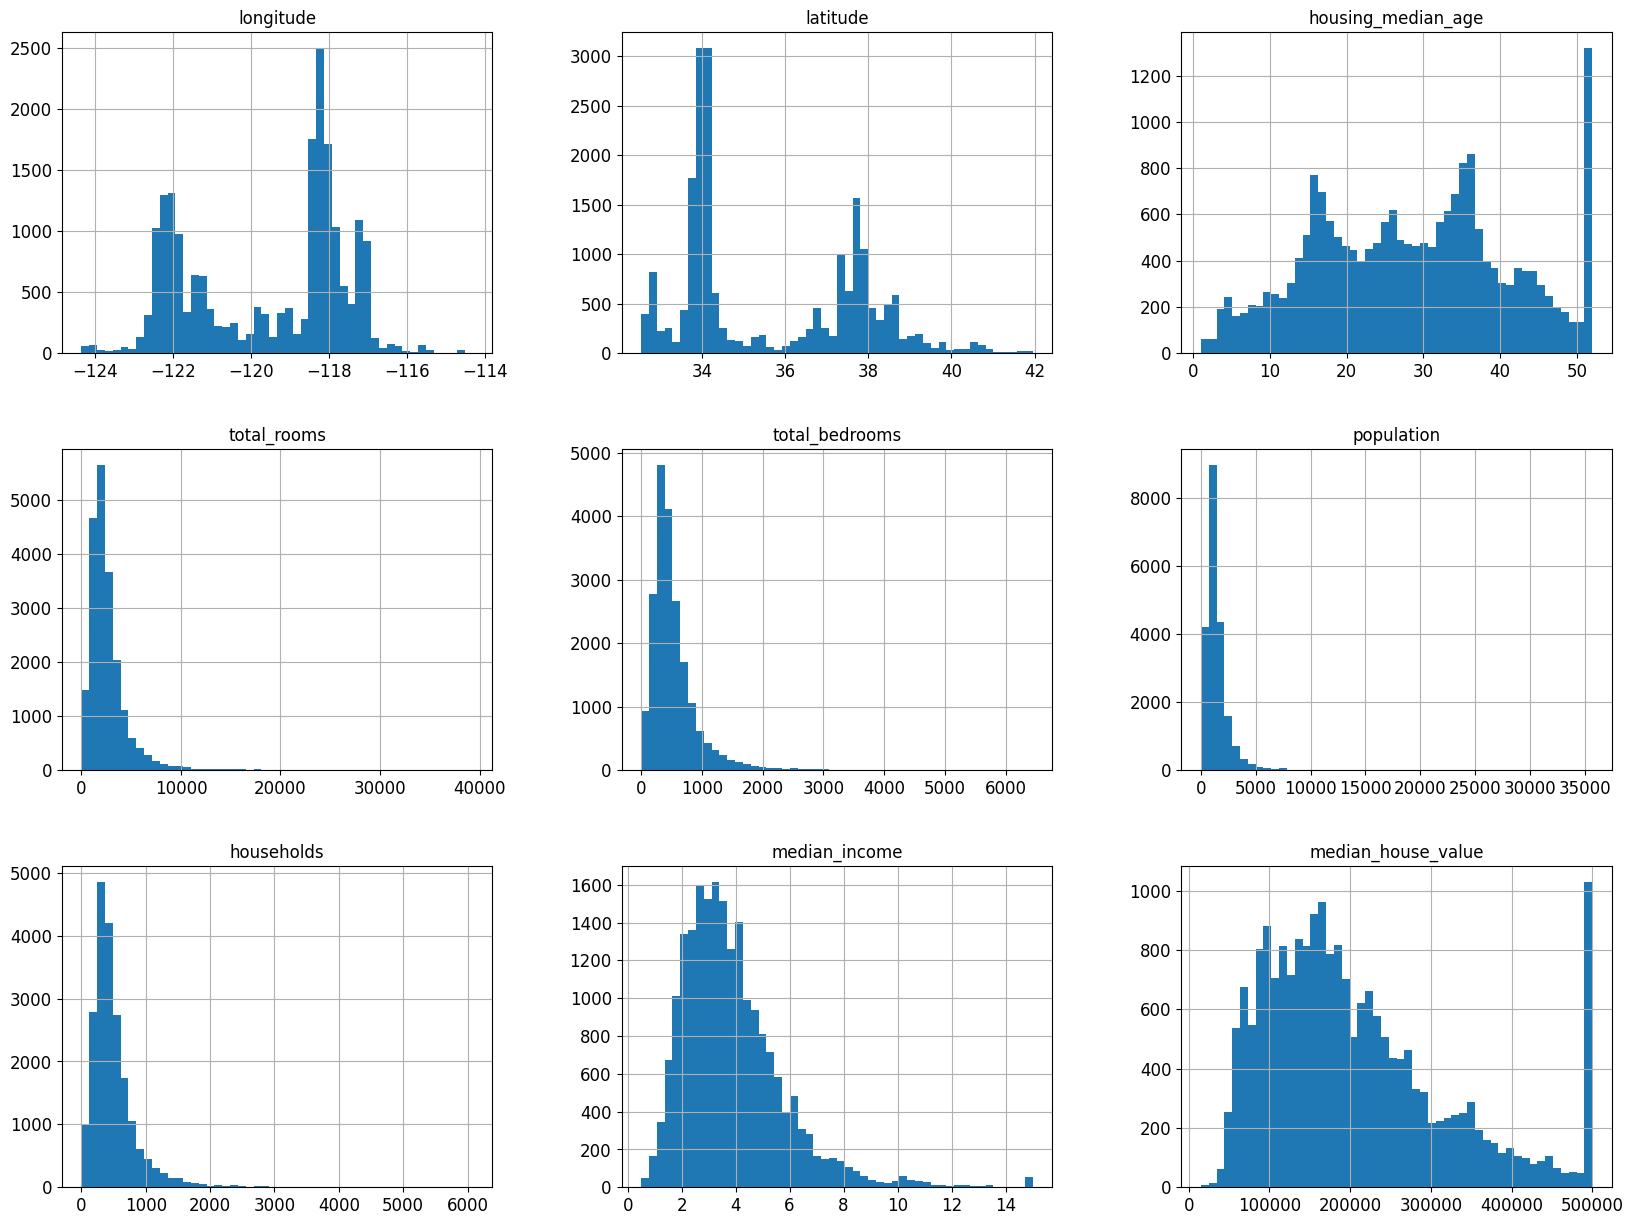

In [14]:
# Distribuicao das frequencias
df_housing.hist(bins=50, figsize=(20,15))
plt.show()

<Axes: xlabel='median_house_value', ylabel='Count'>

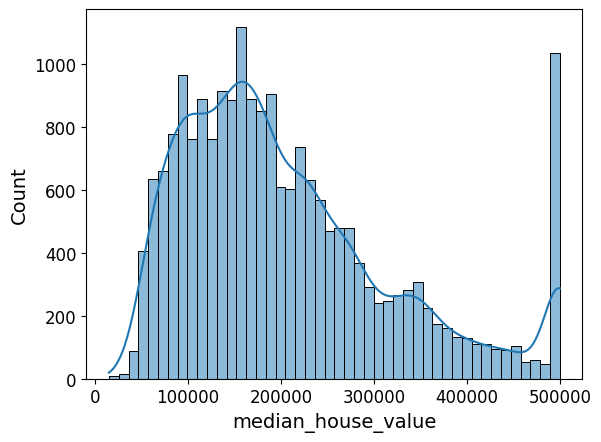

In [15]:
sns.histplot(data=df_housing,x='median_house_value',kde=True)


##### 2. Ferramentas de inferência
 * Teste de hipótese
 * Análise da variância (ANOVA)
 * Teste de chi-quadrado
 * Regressão linear

 ---



---


---


---


---


---


---



### Aula 03 - Relação entre variáveis e extração de características

#### Explorando os dados do problema


##### 1. Seleção das variáveis/características (feature selection)
 * Correlação entre as variáveis de entrada e saída
    * Análise gráfica
    * Coeficiente de correlação linear

<Axes: xlabel='longitude', ylabel='latitude'>

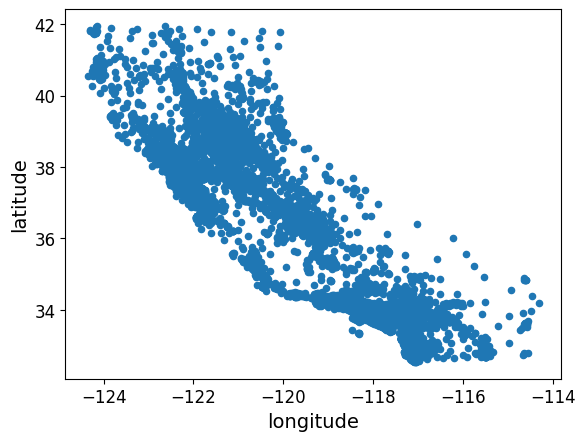

In [ ]:
# Grafico com as posicoes geograficas das casas
df_housing.plot(kind='scatter', x='longitude', y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

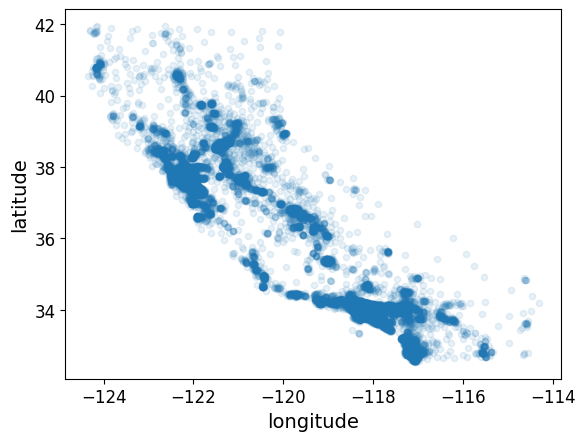

In [ ]:
# Grafico com as posicoes geograficas das casas e marcadores com 10% da cor
df_housing.plot(kind='scatter', x='longitude', y='latitude',alpha=0.1)

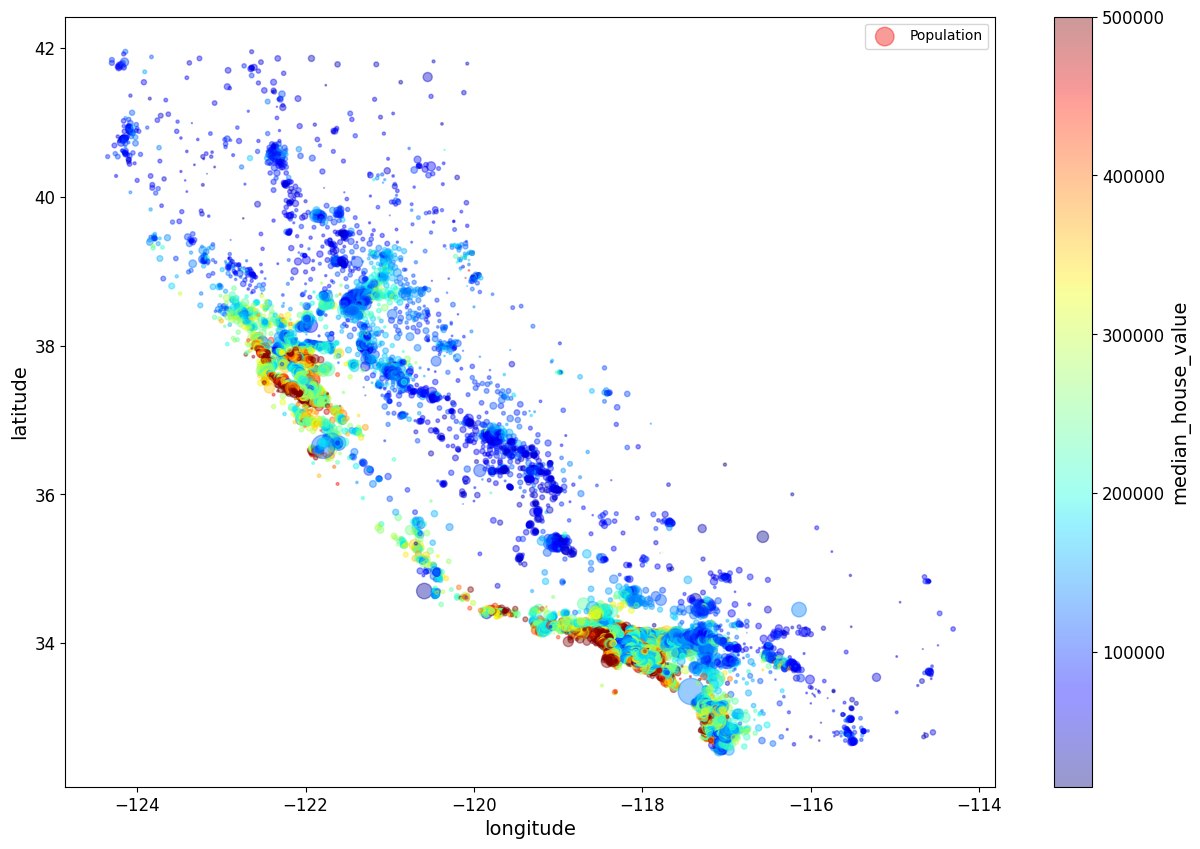

In [ ]:
# Grafico com as posicoes geograficas das casas e marcadores com 40% da cor e modulados pelo 'population'/100 e coloridos de acordo com o valor das casas
df_housing.plot(kind='scatter', x='longitude', y='latitude',alpha=0.4, # posicao geografica
                s=df_housing['population']/100, label='Population', figsize=(15,10), # tamanho do marcado de acordo com a media da populacao no quarteirao
                c='median_house_value',cmap=plt.get_cmap('jet'),colorbar=True) # cor do marcado de acordo com o valor das casas
plt.legend()

In [ ]:
# (Extra) Dispersao das amostras com o mapa da California

import folium
from folium.plugins import MarkerCluster

df_aux = df_housing
map_cahousing = folium.Map(location=[df_aux['latitude'].median(), df_aux['longitude'].median()],
                 zoom_start=6,zoom_control=False, width=800, height=500)

marker_cluster = MarkerCluster().add_to(map_cahousing)

for _, location_info in df_aux.loc[0:,:].iterrows(): #retirar o limite de amostras para plotar com todos os pontos
    folium.Marker([location_info['latitude'], location_info['longitude']],
                    popup=folium.Popup(f"House value: U${location_info['median_house_value']}",max_width=500),
                    icon=folium.Icon(prefix='fa',icon='fa-house'),
                    overlay=True).add_to(marker_cluster)

map_cahousing

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Matriz de correlacao
corr_matrix = df_housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [ ]:
# Correlacao das entradas com a saída desejada
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

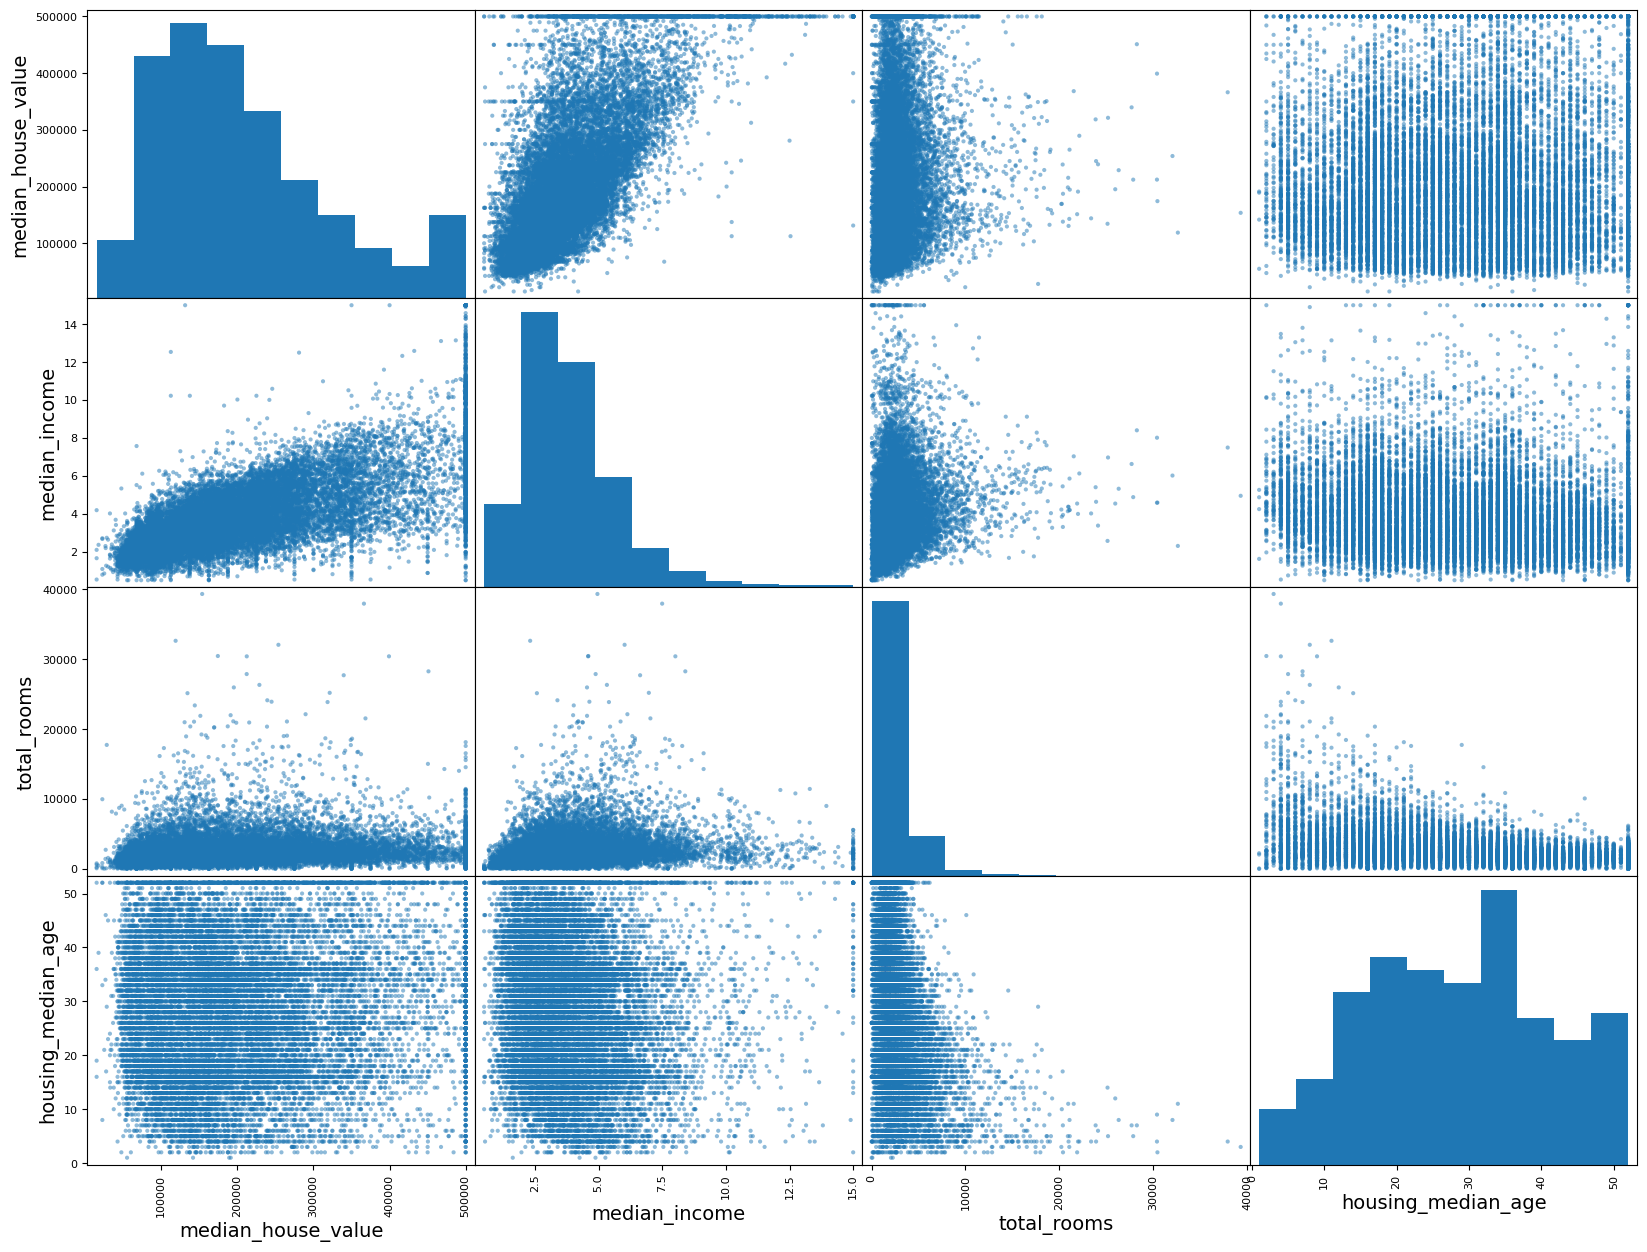

In [ ]:
# Graficos de dispersao entre as variaveis com melhores correlacoes
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
scatter_matrix(df_housing[attributes],figsize=(20,15))

<Axes: xlabel='median_income', ylabel='median_house_value'>

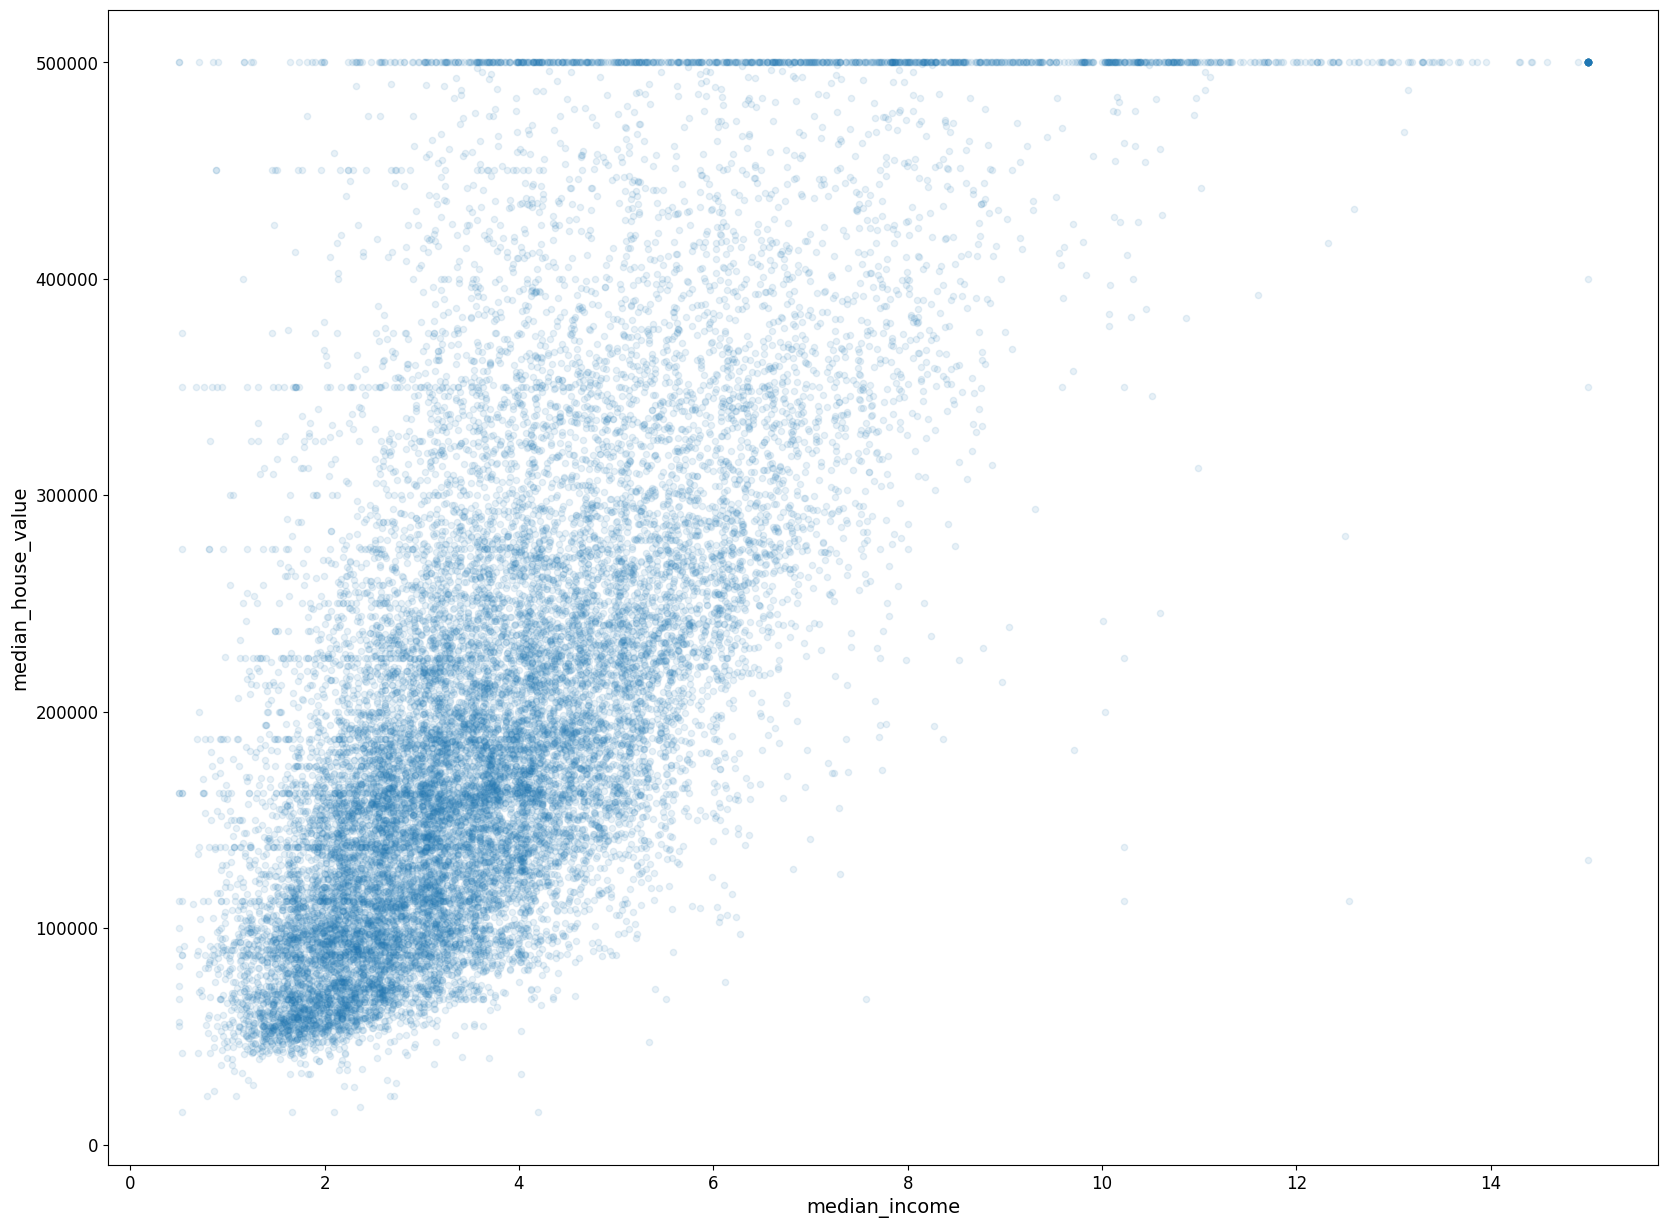

In [ ]:
df_housing.plot(kind='scatter',x='median_income',y='median_house_value',alpha=0.1,figsize=(20,15))

##### 2. Tratamento de variáveis categóricas

###### Transformação de variáveis categóricas em binárias (dummy)
 * **Cuidado ao transformar categóricas ordinárias**


In [ ]:
# Transformando variaveis categoricas

df_housing_cat = df_housing[['ocean_proximity']] #repassa o vetor com os indices
df_housing_cat.value_counts()

ocean_proximity
<1H OCEAN          9136
INLAND             6551
NEAR OCEAN         2658
NEAR BAY           2290
ISLAND                5
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OrdinalEncoder #scikit-learn sera nossa biblioteca principal na disciplina. Muitos metodos estao implementados para serem utilizados
ordinal_encoder = OrdinalEncoder()
df_housing_cat_encoded = ordinal_encoder.fit_transform(df_housing_cat)
df_housing_cat_encoded

array([[3.],
       [3.],
       [3.],
       ...,
       [1.],
       [1.],
       [1.]])

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

*Qual o problema aqui?*
- As categorias ficam ordinárias!


In [ ]:
#One Hot Encoding (variaveis dummies)
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
df_housing_cat_1hot = cat_encoder.fit_transform(df_housing_cat)
df_housing_cat_1hot
# cria uma matriz esparca com as variaveis binarias

<20640x5 sparse matrix of type '<class 'numpy.float64'>'
	with 20640 stored elements in Compressed Sparse Row format>

In [ ]:
#visualizado a matriz esparca
df_housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [ ]:
# categorias transformadas com o OneHotEncoder
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

######  Remoção de variáveis que não acrescentam informações ao modelo
+  Variáveis com apenas um valor
+  Variáveis com muitos dados ausentes

In [ ]:
# Identificando variaveis com dados ausentes ou invalidos
df_housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# Tres formas de fazer o tratamento
df_housing_cleaning = df_housing

In [ ]:
## Metodos mais radicais
### Retira as linhas com dados invalidos
df_housing_cleaning.dropna(subset=['total_bedrooms'])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
### Descarta a coluna 'total_bedrooms'
df_housing_cleaning.drop('total_bedrooms',axis=1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
### Imputa (insere) dados onde esta faltando
median = df_housing['total_bedrooms'].median() # calcula a media dos dados validos
df_housing_cleaning['total_bedrooms'].fillna(median,inplace=True) #substitui os valores invalidos pela media do grupo valido

#### 3. Extração e pré-processamento das variáveis
*Otimizar o número de variáveis sem perder desempenho do modelo*

##### Técnicas de pré-processamento e extração de características
 * Uniformização (xi'= (xi-u)/s):
 ```
 from sklearn.preprocessing import StandardScaler
 ```
 * Normalização
 ```
 from sklearn.preprocessing import MinMaxScaler
 ```
 * Melhoramento da relação sinal/ruído
 * Redução de dimensionalidade
  * Cada problema requer um método diferente. Depende da análise

###### Combinação de variáveis?
- *É possível criar novas variáveis a partir das variáveis do problema?*

- As variáveis *total_bedrooms*, *total_rooms* e *population* sozinhas fazem algum sentido para quem vai comprar uma casa?

In [ ]:
df_housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
# Criando novas variaveis para analisar o problema
df_housing["rooms_per_household"] = df_housing["total_rooms"]/df_housing["households"]
df_housing["population_per_household"]= df_housing["population"]/df_housing["households"]

corr_matrix = df_housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049457
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
Name: median_house_value, dtype: float64

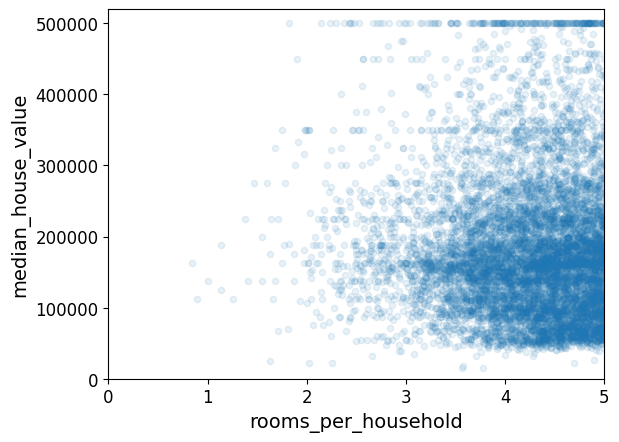

In [ ]:
df_housing.plot(kind='scatter', x='rooms_per_household',y='median_house_value', alpha = 0.1)
plt.axis([0,5,0,520000])
plt.show()